# Dataset 1 — Multi-Day TEC Forecasting Workflow

| Target Day | Note |
|---|---|
| Day 33 | 33rd chronological day |
| Day 37 | 37th chronological day |
| Day 40 | 40th chronological day |
| Day 41 | 41st chronological day (final day) |

All heavy logic lives under `src/`. This notebook only calls functions.

**Flow** (mirrors the single-file reference notebook):
1. Imports
2. Load Dataset 1 and sort it
3. Build matrix, train LSTM & Transformer once, then forecast each target day
   (using the previous day as input) and compute ionospheric delays
4. Plots (generated for every target day) — LSTM/Transformer loss curves,
   actual vs predicted (LSTM & Transformer), L1+L5 combined ionospheric delay
5. Event-threshold metrics (3 m / 8 m / 15 m) for LSTM & Transformer, L1 & L5,
   for every target day, plus a TEC-level RMSE/MAE summary table


---
### Imports

In [1]:
import torch
import numpy as np
import pandas as pd

from src.preprocessing.sort_tec_data import build_sorted_dataset
from src.preprocessing.dataset import prepare_dataset
from src.configs.config import (
    BASE_DIR_1, OUTPUT_DIR_1, PLOTS_DIR_1, GENERATED_PLOTS_DIR,
    F_L1, F_L5,
    EVENT_THRESHOLD_PERCENTILE, DELAY_EVENT_THRESHOLDS_M,
    TARGET_DAYS,
    get_date_label,
)
from src.training.lstm_training import train_lstm
from src.training.transformer_training import train_transformer
from src.plots.loss_plots import plot_lstm_loss, plot_transformer_loss
from src.plots.prediction_plots import plot_lstm_prediction, plot_transformer_prediction
from src.plots.delay_plots import (
    plot_lstm_delay_l1_l5_combined,
    plot_transformer_delay_l1_l5_combined,
)
from src.utils.iono_delay import delay_metrics, tec_to_iono_delay, compute_all_delays
from src.utils.save_results import save_delay_csv
from src.utils.metrics import (
    rmse,
    pearson_correlation,
    probability_of_detection,
    critical_success_index,
    f1_score,
    false_alarm_ratio,
)

# This notebook always targets Dataset 1 — used for filenames, labels, and
# looking up real calendar dates via get_date_label(DATASET_NO, day).
DATASET_NO = 1


---
# Dataset 1 — Forecasting Workflow (Days {TARGET_DAYS})
---

### 1. Base Directory and Output Setup — Dataset 1

In [2]:
print(f"Base directory 1  : {BASE_DIR_1}")
print(f"Output directory 1: {OUTPUT_DIR_1}")
print(f"Target days        : {TARGET_DAYS}")

Base directory 1  : c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1
Output directory 1: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet
Target days        : (33, 37, 40, 41)


### 2. Creating Sorted TEC Dataset — Dataset 1
```text
Process the raw per-satellite folders and create one sorted CSV per folder
containing the maximum TEC value for each minute.
Returns: Number of output CSV files written.
```

In [3]:
written_files_1 = build_sorted_dataset(1)

print("TEC data sorting completed — Dataset 1.")
print(f"Number of output CSV files written: {written_files_1}")
print(f"Saved sorted CSV files to: {OUTPUT_DIR_1}")

TEC data sorting completed — Dataset 1.
Number of output CSV files written: 41
Saved sorted CSV files to: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet


#### QUICK SANITY CHECK — Dataset 1
> Print first 6 lines of the first output file

In [4]:
sample_file_1 = OUTPUT_DIR_1 / "iisc1290_TECU_sorted.csv"
if sample_file_1.exists():
    with sample_file_1.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file_1}")

Time(UTC),TEC(TECU)
09-05-23 00:00,42.390972
09-05-23 00:01,51.206161
09-05-23 00:02,32.852289
09-05-23 00:03,34.870453
09-05-23 00:04,39.373245


### 3. Data Loading and Preprocessing — Dataset 1
```text
Loads sorted CSVs into a (days x minutes) numpy matrix,
builds supervised input/target pairs, and
normalises using training stats only.
```

In [5]:
X_train_1, y_train_1, X_val_1, y_val_1, stats_1, daily_matrix_1, daily_files_1 = prepare_dataset(1)

print(f"X_train : {X_train_1.shape}   y_train : {y_train_1.shape}")
print(f"X_val   : {X_val_1.shape}     y_val   : {y_val_1.shape}")
print(f"Norm stats : {stats_1}")

X_train : (29, 1440, 1)   y_train : (29, 1440, 1)
X_val   : (11, 1440, 1)     y_val   : (11, 1440, 1)
Norm stats : {'x_mean': 87.88667297363281, 'x_std': 45.894798288808595, 'y_mean': 86.92459106445312, 'y_std': 45.30130768822266}


### 4. LSTM Training Workflow — Dataset 1

> Dataset consists of 41 chronologically sorted TEC files.

```text
Training Set
------------
Input  : Days  1-29
Target : Days  2-30

Validation Set
--------------
Input  : Days 30-40
Target : Days 31-41

Forecast (per target day)
--------------------------
Input  : Day (target - 1)
Output : Day target
```

In [6]:
lstm_model_1, lstm_history_1 = train_lstm(X_train_1, y_train_1, X_val_1, y_val_1)

Epoch 1/50 — loss: 0.970071 — val_loss: 0.703141
Epoch 2/50 — loss: 0.796376 — val_loss: 0.484105
Epoch 3/50 — loss: 0.379775 — val_loss: 0.139985
Epoch 4/50 — loss: 0.206873 — val_loss: 0.170383
Epoch 5/50 — loss: 0.157360 — val_loss: 0.136358
Epoch 6/50 — loss: 0.162006 — val_loss: 0.129844
Epoch 7/50 — loss: 0.146071 — val_loss: 0.134694
Epoch 8/50 — loss: 0.148146 — val_loss: 0.128769
Epoch 9/50 — loss: 0.141884 — val_loss: 0.126743
Epoch 10/50 — loss: 0.142981 — val_loss: 0.124715
Epoch 11/50 — loss: 0.134841 — val_loss: 0.125377
Epoch 12/50 — loss: 0.138120 — val_loss: 0.117390
Epoch 13/50 — loss: 0.129662 — val_loss: 0.117523
Epoch 14/50 — loss: 0.130526 — val_loss: 0.114831
Epoch 15/50 — loss: 0.134959 — val_loss: 0.116569
Epoch 16/50 — loss: 0.126524 — val_loss: 0.116000
Epoch 17/50 — loss: 0.135709 — val_loss: 0.118328
Epoch 18/50 — loss: 0.125984 — val_loss: 0.119945
Epoch 19/50 — loss: 0.124353 — val_loss: 0.115734
Epoch 20/50 — loss: 0.129371 — val_loss: 0.115576
Epoch 21/

### 5. LSTM Loss and Validation Curve — Dataset 1

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\loss_LSTM_dataset1.png


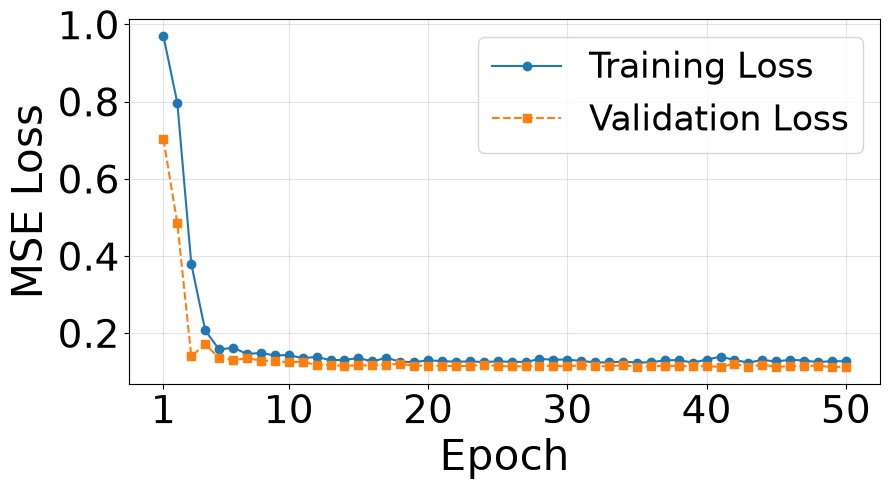

Final train loss : 0.126803
Final val   loss : 0.113233


In [7]:
plot_lstm_loss(lstm_history_1, dataset_label="dataset1", output_dir=str(PLOTS_DIR_1))

### 6. Transformer Training Workflow — Dataset 1

In [8]:
transformer_model_1, transformer_history_1 = train_transformer(X_train_1, y_train_1, X_val_1, y_val_1)

[Transformer] Training on: cpu
TECTransformerEncoder(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (output_proj): Linear(in_features=64, 

c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\src\models\transformer_model.py:101: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/50 | loss: 2.577085 | val_loss: 2.360261 | lr: 1.14e-05
Epoch   2/50 | loss: 2.481625 | val_loss: 2.054646 | lr: 2.29e-05
Epoch   3/50 | loss: 2.238166 | val_loss: 1.708990 | lr: 3.43e-05
Epoch   4/50 | loss: 1.943856 | val_loss: 1.373218 | lr: 4.57e-05
Epoch   5/50 | loss: 1.642516 | val_loss: 1.052700 | lr: 5.71e-05
Epoch   6/50 | loss: 1.299940 | val_loss: 0.768088 | lr: 6.86e-05
Epoch   7/50 | loss: 1.001292 | val_loss: 0.557244 | lr: 8.00e-05
Epoch   8/50 | loss: 0.774300 | val_loss: 0.408954 | lr: 9.14e-05
Epoch   9/50 | loss: 0.609417 | val_loss: 0.296289 | lr: 1.00e-04
Epoch  10/50 | loss: 0.486653 | val_loss: 0.215877 | lr: 9.97e-05
Epoch  11/50 | loss: 0.402370 | val_loss: 0.172543 | lr: 9.90e-05
Epoch  12/50 | loss: 0.347721 | val_loss: 0.157285 | lr: 9.79e-05
Epoch  13/50 | loss: 0.328952 | val_loss: 0.145738 | lr: 9.64e-05
Epoch  14/50 | loss: 0.294915 | val_loss: 0.139844 | lr: 9.46e-05
Epoch  15/50 | loss: 0.286239 | val_loss: 0.132765 | lr: 9.24e-05
Epoch  16/

### 7. Transformer Loss and Validation Curve — Dataset 1

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\loss_transformer_dataset1.png


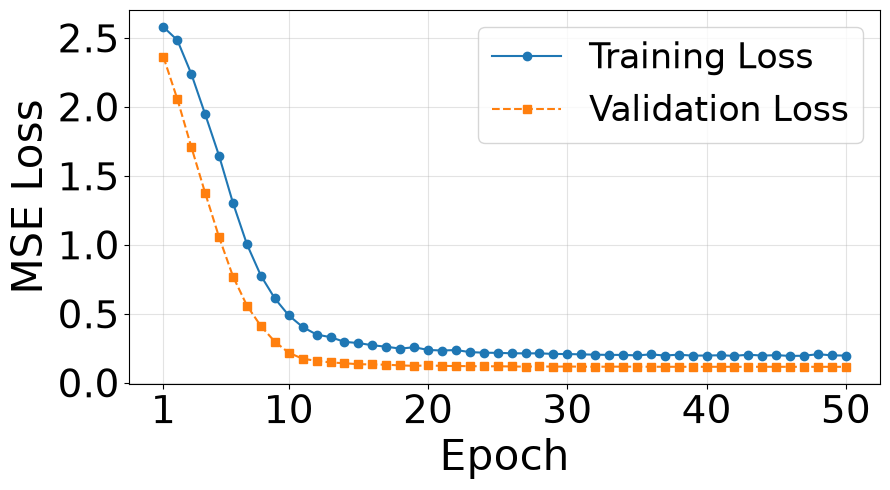

Final train loss : 0.195501
Final val   loss : 0.113853


In [9]:
plot_transformer_loss(transformer_history_1, dataset_label="dataset1", output_dir=str(PLOTS_DIR_1))

### 8. Forecast Every Target Day — Dataset 1

For each day in `TARGET_DAYS`, the previous day's TEC is fed in as input and
both trained models forecast the target day. Actual, LSTM-predicted, and
Transformer-predicted TEC (plus their L1 ionospheric delays) are collected
into `results_1[day]` for use by every plotting/metrics cell below.

In [10]:
x_mean_1, x_std_1 = stats_1["x_mean"], stats_1["x_std"]
y_mean_1, y_std_1 = stats_1["y_mean"], stats_1["y_std"]

device = next(lstm_model_1.parameters()).device
lstm_model_1.eval()
transformer_model_1.eval()

# results_1[day] = dict(actual=..., lstm_pred=..., trans_pred=..., date_label=...,
#                         iono_actual=..., iono_lstm=..., iono_trans=...)
results_1 = {}

for day in TARGET_DAYS:
    input_day_raw = daily_matrix_1[day - 2]   # day N-1 -> predicts day N
    actual_day    = daily_matrix_1[day - 1]

    input_norm = ((input_day_raw - x_mean_1) / x_std_1)[np.newaxis, ..., np.newaxis]
    src = torch.tensor(input_norm, dtype=torch.float32).to(device)

    with torch.no_grad():
        lstm_pred_norm  = lstm_model_1(src).squeeze().cpu().numpy()
        trans_pred_norm = transformer_model_1(src).squeeze().cpu().numpy()

    lstm_pred_day  = lstm_pred_norm  * y_std_1 + y_mean_1
    trans_pred_day = trans_pred_norm * y_std_1 + y_mean_1

    date_label_day = get_date_label(DATASET_NO, day)

    results_1[day] = dict(
        actual=actual_day,
        lstm_pred=lstm_pred_day,
        trans_pred=trans_pred_day,
        date_label=date_label_day,
        iono_actual=tec_to_iono_delay(actual_day),
        iono_lstm=tec_to_iono_delay(lstm_pred_day),
        iono_trans=tec_to_iono_delay(trans_pred_day),
    )

    print(f"Forecast day: {day}  ({date_label_day or 'date unknown'})  -- done")

Forecast day: 33  (date unknown)  -- done
Forecast day: 37  (date unknown)  -- done
Forecast day: 40  (date unknown)  -- done
Forecast day: 41  (date unknown)  -- done


### 9. Actual vs Predicted TEC Plots — Dataset 1 (every target day)


Day 33  (date unknown)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_LSTM_day33_dataset1.png


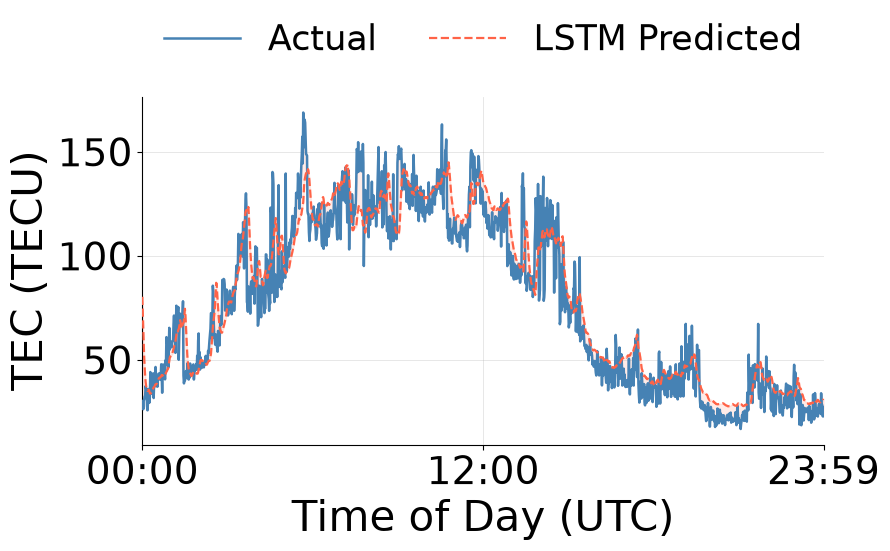

LSTM Day-33 RMSE : 12.7942 TECU
LSTM Day-33 MAE  : 9.5431 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_transformer_day33_dataset1.png


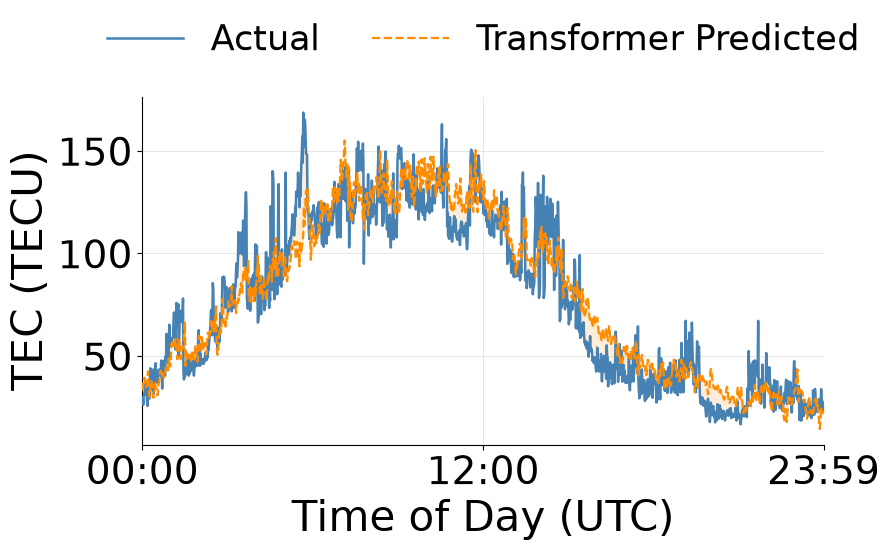

Transformer Day-33 RMSE : 13.7158 TECU
Transformer Day-33 MAE  : 10.8982 TECU

Day 37  (date unknown)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_LSTM_day37_dataset1.png


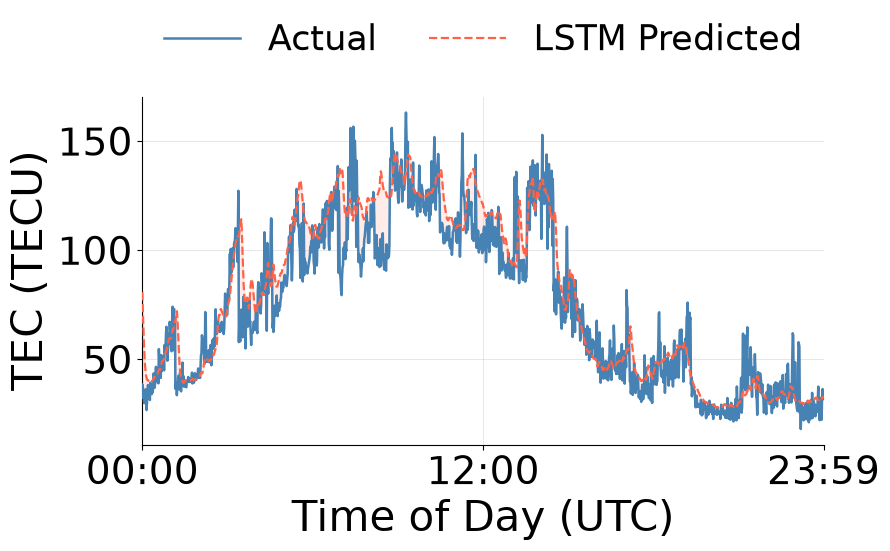

LSTM Day-37 RMSE : 13.6449 TECU
LSTM Day-37 MAE  : 9.7399 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_transformer_day37_dataset1.png


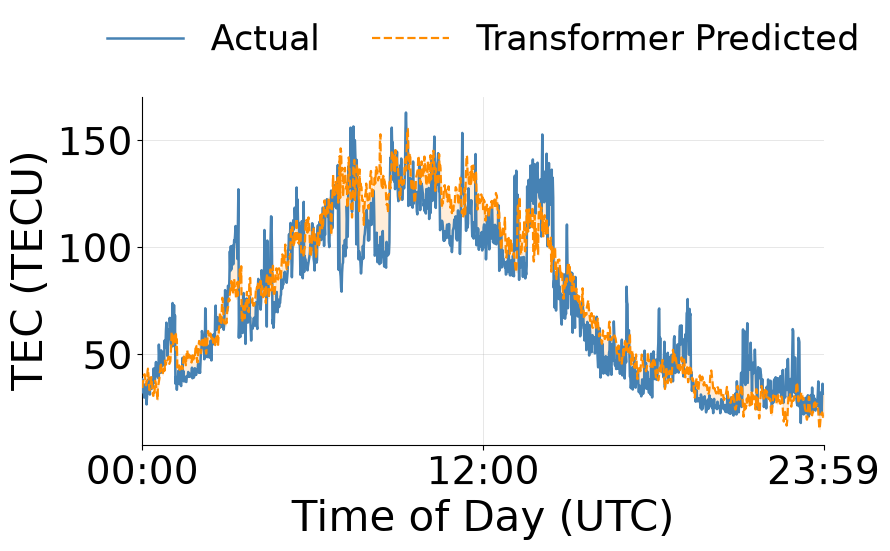

Transformer Day-37 RMSE : 14.8076 TECU
Transformer Day-37 MAE  : 11.5572 TECU

Day 40  (date unknown)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_LSTM_day40_dataset1.png


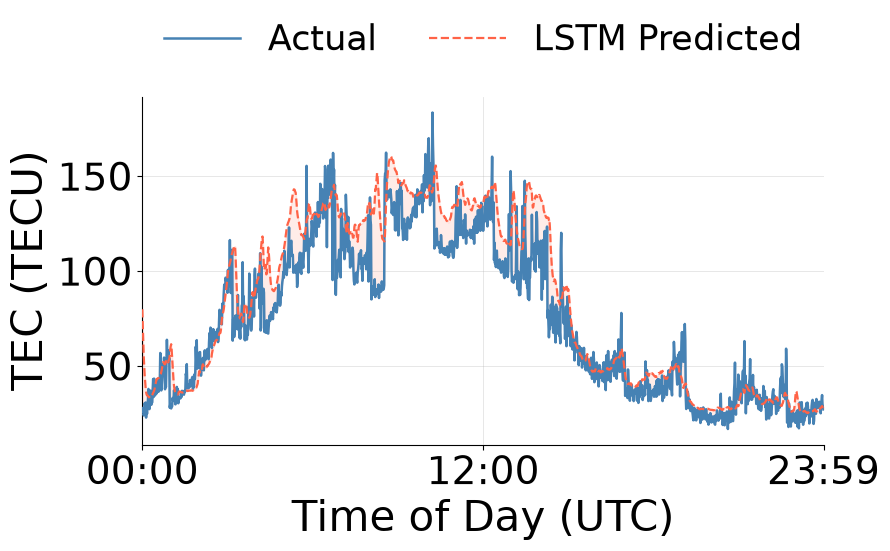

LSTM Day-40 RMSE : 17.3507 TECU
LSTM Day-40 MAE  : 12.5174 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_transformer_day40_dataset1.png


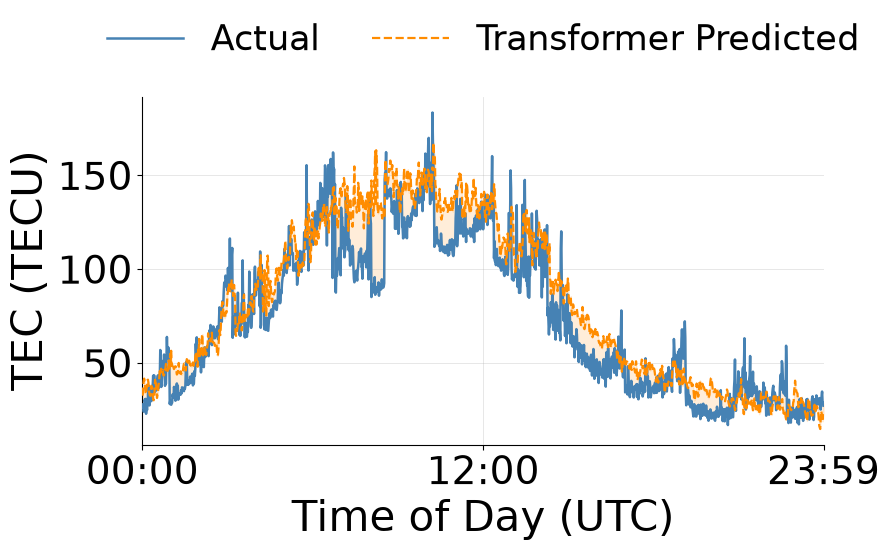

Transformer Day-40 RMSE : 16.8369 TECU
Transformer Day-40 MAE  : 13.1310 TECU

Day 41  (date unknown)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_LSTM_day41_dataset1.png


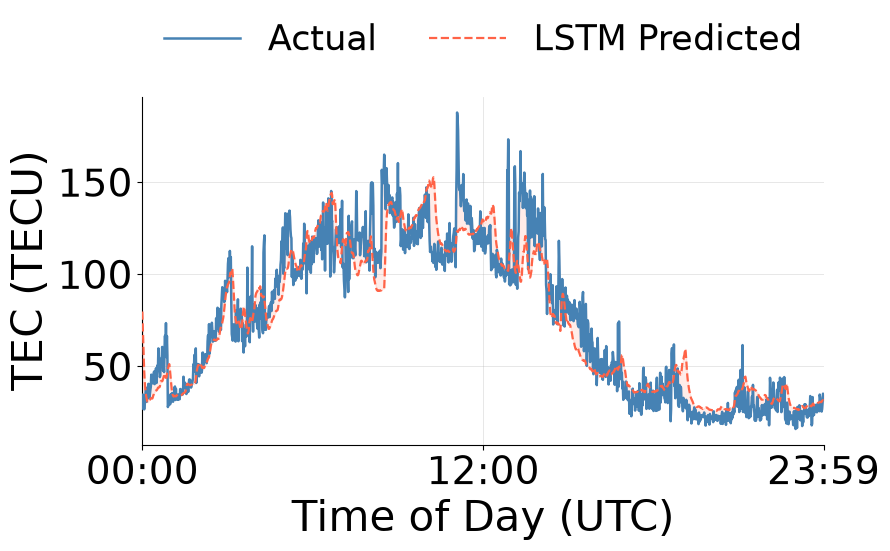

LSTM Day-41 RMSE : 15.3465 TECU
LSTM Day-41 MAE  : 11.0779 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_transformer_day41_dataset1.png


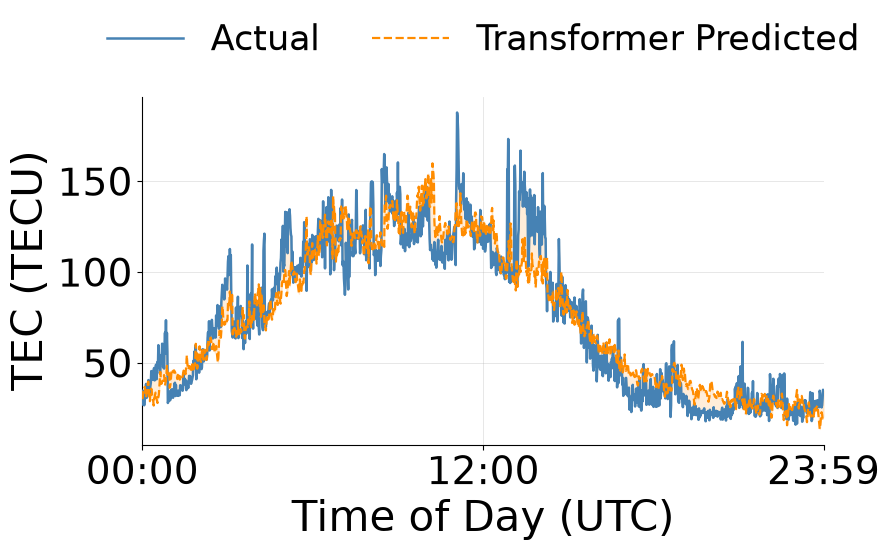

Transformer Day-41 RMSE : 14.8659 TECU
Transformer Day-41 MAE  : 10.9083 TECU


In [11]:
tec_metrics_1 = {}   # tec_metrics_1[day] = dict(lstm_rmse=, lstm_mae=, trans_rmse=, trans_mae=)

for day in TARGET_DAYS:
    r = results_1[day]
    print(f"\n{'=' * 70}\nDay {day}  ({r['date_label'] or 'date unknown'})\n{'=' * 70}")

    lstm_rmse_d, lstm_mae_d = plot_lstm_prediction(
        r["actual"], r["lstm_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_1),
    )
    trans_rmse_d, trans_mae_d = plot_transformer_prediction(
        r["actual"], r["trans_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_1),
    )

    tec_metrics_1[day] = dict(
        lstm_rmse=lstm_rmse_d, lstm_mae=lstm_mae_d,
        trans_rmse=trans_rmse_d, trans_mae=trans_mae_d,
    )

### 10. L1 + L5 Combined Ionospheric Delay Plots — Dataset 1 (every target day)


Day 33  (date unknown) -- L1+L5 combined delay
LSTM L1 — RMSE: 2.07784 m   MAE: 1.54984 m
LSTM L5 — RMSE: 3.72614 m   MAE: 2.77928 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_LSTM_L1_L5_combined_day33_dataset1.png


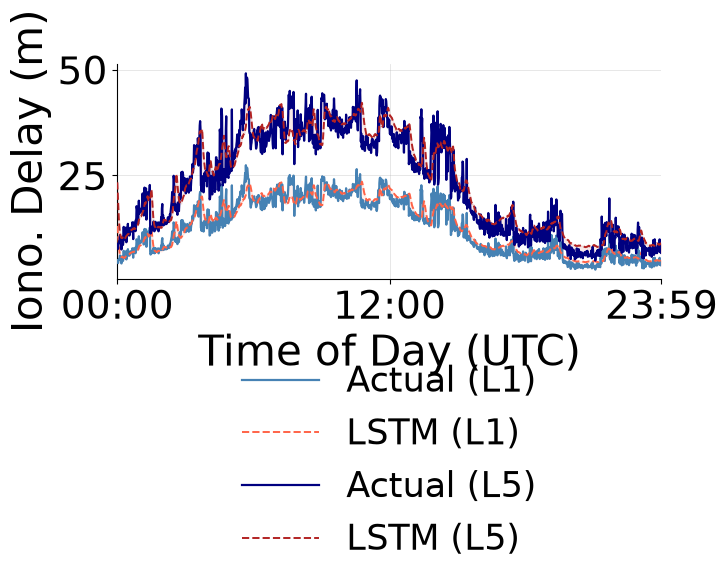

Transformer L1 — RMSE: 2.22751 m   MAE: 1.76993 m
Transformer L5 — RMSE: 3.99452 m   MAE: 3.17396 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_transformer_L1_L5_combined_day33_dataset1.png


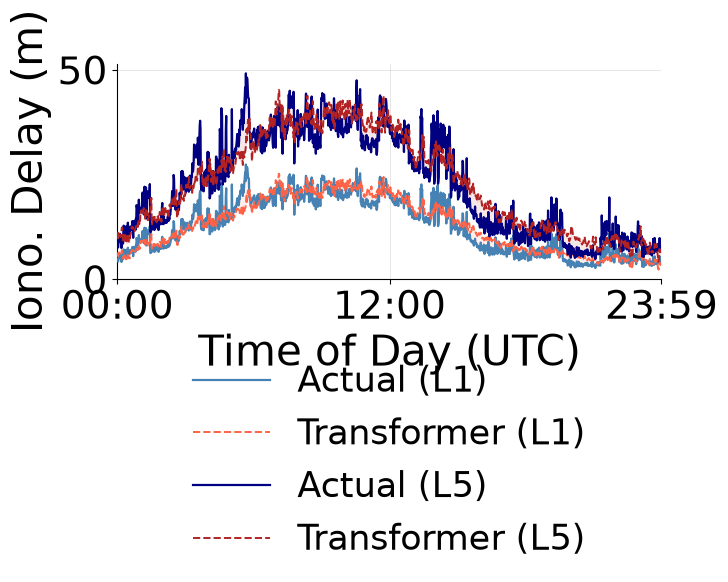


Day 37  (date unknown) -- L1+L5 combined delay
LSTM L1 — RMSE: 2.21600 m   MAE: 1.58181 m
LSTM L5 — RMSE: 3.97388 m   MAE: 2.83661 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_LSTM_L1_L5_combined_day37_dataset1.png


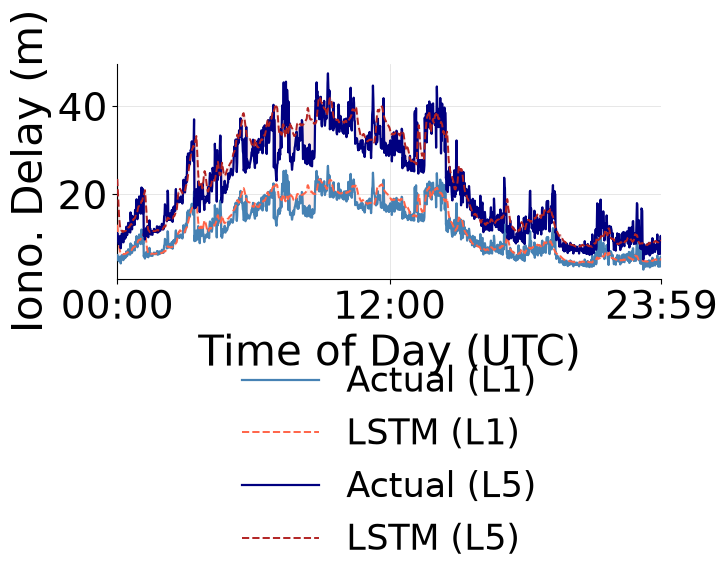

Transformer L1 — RMSE: 2.40482 m   MAE: 1.87694 m
Transformer L5 — RMSE: 4.31248 m   MAE: 3.36586 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_transformer_L1_L5_combined_day37_dataset1.png


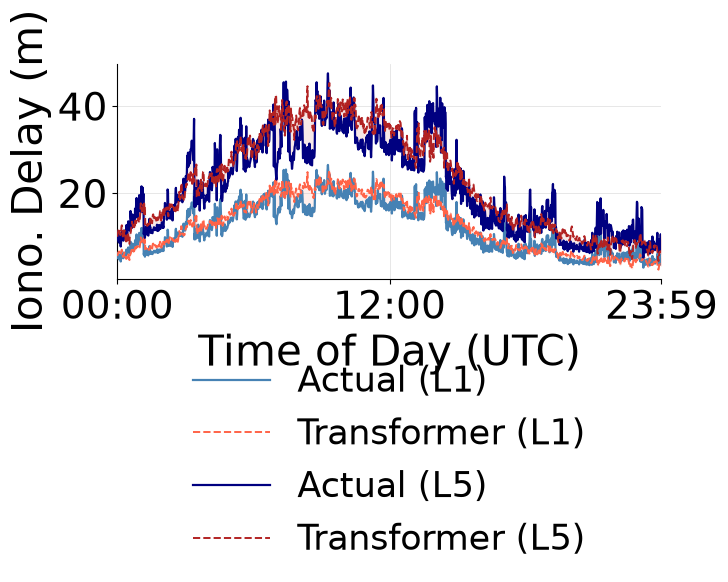


Day 40  (date unknown) -- L1+L5 combined delay
LSTM L1 — RMSE: 2.81784 m   MAE: 2.03288 m
LSTM L5 — RMSE: 5.05314 m   MAE: 3.64550 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_LSTM_L1_L5_combined_day40_dataset1.png


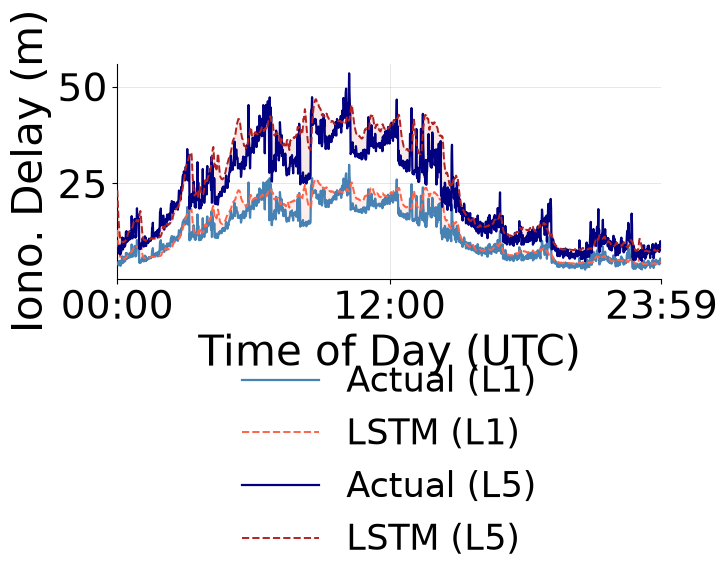

Transformer L1 — RMSE: 2.73439 m   MAE: 2.13254 m
Transformer L5 — RMSE: 4.90349 m   MAE: 3.82423 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_transformer_L1_L5_combined_day40_dataset1.png


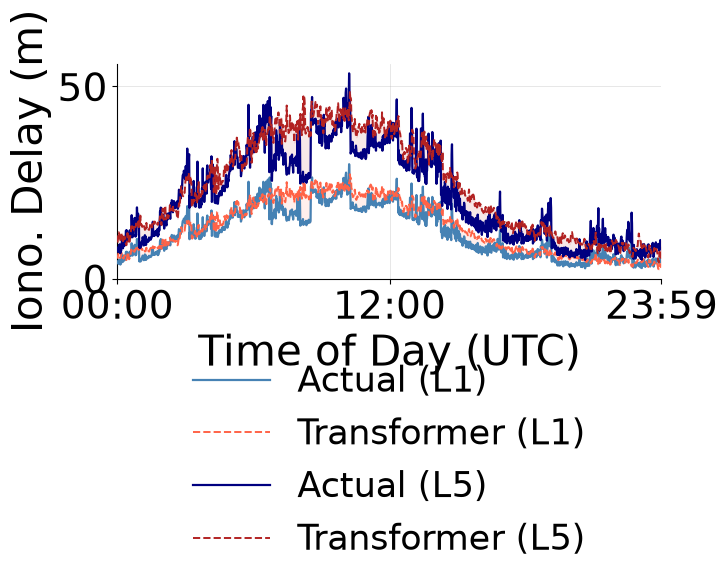


Day 41  (date unknown) -- L1+L5 combined delay
LSTM L1 — RMSE: 2.49234 m   MAE: 1.79910 m
LSTM L5 — RMSE: 4.46943 m   MAE: 3.22628 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_LSTM_L1_L5_combined_day41_dataset1.png


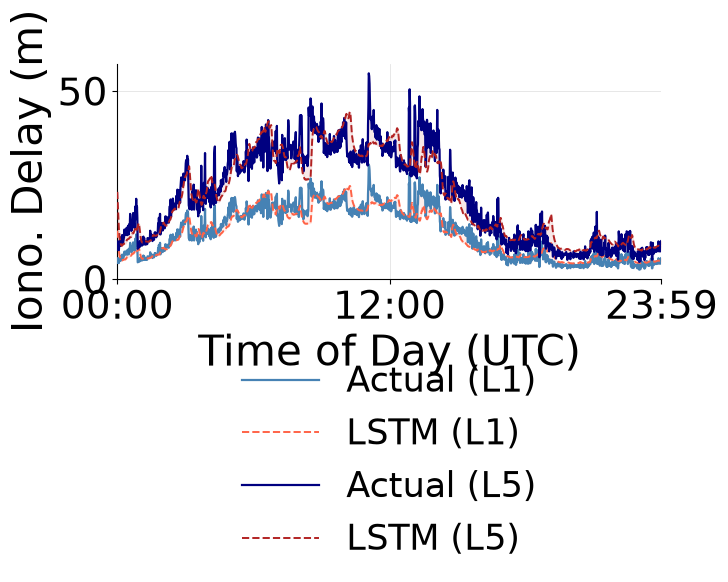

Transformer L1 — RMSE: 2.41429 m   MAE: 1.77157 m
Transformer L5 — RMSE: 4.32948 m   MAE: 3.17690 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_transformer_L1_L5_combined_day41_dataset1.png


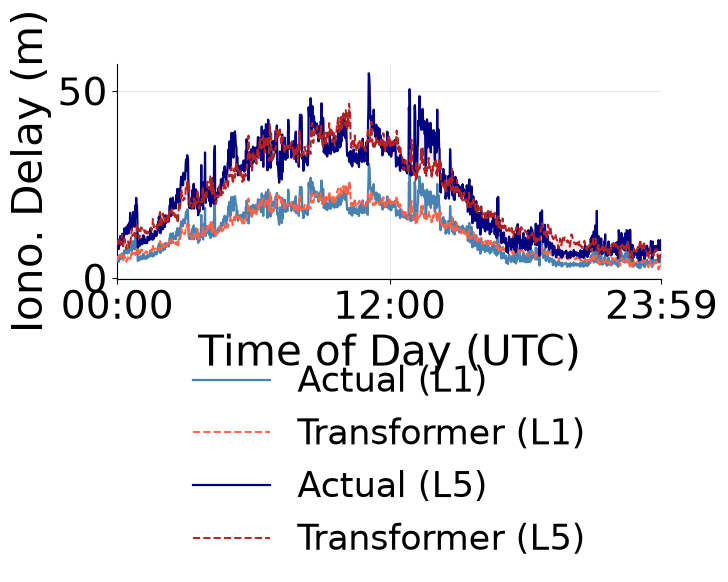

In [12]:
for day in TARGET_DAYS:
    r = results_1[day]
    print(f"\n{'=' * 70}\nDay {day}  ({r['date_label'] or 'date unknown'}) -- L1+L5 combined delay\n{'=' * 70}")

    plot_lstm_delay_l1_l5_combined(
        r["actual"], r["lstm_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_1),
    )
    plot_transformer_delay_l1_l5_combined(
        r["actual"], r["trans_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_1),
    )

### 11. Delay Error Metrics (L1, vertical) — Dataset 1 (every target day)

In [13]:
for day in TARGET_DAYS:
    r = results_1[day]
    print(f"\nIonospheric Delay Error (L1, vertical) — Day {day} ({r['date_label'] or 'date unknown'}) — Dataset {DATASET_NO}")
    print("=" * 70)
    delay_metrics("LSTM",        r["iono_lstm"],  r["iono_actual"])
    delay_metrics("Transformer", r["iono_trans"], r["iono_actual"])


Ionospheric Delay Error (L1, vertical) — Day 33 (date unknown) — Dataset 1
LSTM             RMSE = 2.07784 m   MAE = 1.54984 m   Bias = +0.45993 m
Transformer      RMSE = 2.22751 m   MAE = 1.76993 m   Bias = +0.24180 m

Ionospheric Delay Error (L1, vertical) — Day 37 (date unknown) — Dataset 1
LSTM             RMSE = 2.21600 m   MAE = 1.58181 m   Bias = +0.68306 m
Transformer      RMSE = 2.40482 m   MAE = 1.87694 m   Bias = +0.52974 m

Ionospheric Delay Error (L1, vertical) — Day 40 (date unknown) — Dataset 1
LSTM             RMSE = 2.81784 m   MAE = 2.03288 m   Bias = +1.40105 m
Transformer      RMSE = 2.73439 m   MAE = 2.13254 m   Bias = +1.28869 m

Ionospheric Delay Error (L1, vertical) — Day 41 (date unknown) — Dataset 1
LSTM             RMSE = 2.49234 m   MAE = 1.79910 m   Bias = -0.11491 m
Transformer      RMSE = 2.41429 m   MAE = 1.77157 m   Bias = -0.07010 m


### 12. Save Forecast Output CSVs — Dataset 1 (every target day)

In [14]:
for day in TARGET_DAYS:
    r = results_1[day]
    save_delay_csv(
        r["actual"], r["lstm_pred"], r["trans_pred"],
        output_dir=OUTPUT_DIR_1,
        filename=f"day{day}_ionospheric_delay.csv",
    )

Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet\day33_ionospheric_delay.csv
Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet\day37_ionospheric_delay.csv
Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet\day40_ionospheric_delay.csv
Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet\day41_ionospheric_delay.csv


---
## Event-Threshold Metrics — Dataset 1

High-TEC threshold event detection at L1 and L5 ionospheric-delay thresholds
(3 m / 8 m / 15 m) for every target day, for both LSTM and Transformer.

In [15]:
freqs = {"L1": F_L1, "L5": F_L5}
event_rows_1 = []

for day in TARGET_DAYS:
    r = results_1[day]
    actual_day, lstm_pred_day, trans_pred_day = r["actual"], r["lstm_pred"], r["trans_pred"]

    for freq_label, freq_hz in freqs.items():
        iono_actual_f, iono_lstm_f, iono_trans_f = compute_all_delays(
            actual_day, lstm_pred_day, trans_pred_day, frequency=freq_hz
        )

        for model_name, pred_delay in (("LSTM", iono_lstm_f), ("Transformer", iono_trans_f)):
            overall_rmse = rmse(pred_delay, iono_actual_f)
            overall_corr = pearson_correlation(pred_delay, iono_actual_f)

            for thr in DELAY_EVENT_THRESHOLDS_M:
                pod = probability_of_detection(pred_delay, iono_actual_f, threshold=thr)
                csi = critical_success_index(pred_delay, iono_actual_f, threshold=thr)
                f1  = f1_score(pred_delay, iono_actual_f, threshold=thr)
                far = false_alarm_ratio(pred_delay, iono_actual_f, threshold=thr)

                event_rows_1.append({
                    "Day": day,
                    "Date": r["date_label"] or f"day{day}",
                    "Frequency": freq_label,
                    "Model": model_name,
                    "Threshold (m)": thr,
                    "Delay RMSE (m)": overall_rmse,
                    "Delay Correlation": overall_corr,
                    "POD": pod,
                    "CSI": csi,
                    "F1 Score": f1,
                    "FAR": far,
                })

event_metrics_table_1 = pd.DataFrame(event_rows_1).round(4)
print(f"Event-threshold metrics -- Dataset {DATASET_NO}, Days {TARGET_DAYS}")
print(event_metrics_table_1.to_string(index=False))

summary_csv_path_1 = GENERATED_PLOTS_DIR / f"event_threshold_metrics_dataset{DATASET_NO}.csv"
GENERATED_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
event_metrics_table_1.to_csv(summary_csv_path_1, index=False)
print(f"\nSaved event-threshold metrics table to: {summary_csv_path_1}")

event_metrics_table_1

Event-threshold metrics -- Dataset 1, Days (33, 37, 40, 41)
 Day  Date Frequency       Model  Threshold (m)  Delay RMSE (m)  Delay Correlation    POD    CSI  F1 Score    FAR
  33 day33        L1        LSTM            3.0          2.0778             0.9519 1.0000 0.9972    0.9986 0.0028
  33 day33        L1        LSTM            8.0          2.0778             0.9519 0.9609 0.8776    0.9348 0.0899
  33 day33        L1        LSTM           15.0          2.0778             0.9519 0.9673 0.8477    0.9176 0.1273
  33 day33        L1 Transformer            3.0          2.2275             0.9425 0.9972 0.9944    0.9972 0.0028
  33 day33        L1 Transformer            8.0          2.2275             0.9425 0.9598 0.8616    0.9256 0.1061
  33 day33        L1 Transformer           15.0          2.2275             0.9425 0.9191 0.8292    0.9066 0.1055
  33 day33        L5        LSTM            3.0          3.7261             0.9519 1.0000 1.0000    1.0000 0.0000
  33 day33        L5        

,Day,Date,Frequency,Model,Threshold (m),Delay RMSE (m),Delay Correlation,POD,CSI,F1 Score,FAR
0,33,day33,L1,LSTM,3.0,2.0778,0.9519,1.0000,0.9972,0.9986,0.0028
1,33,day33,L1,LSTM,8.0,2.0778,0.9519,0.9609,0.8776,0.9348,0.0899
2,33,day33,L1,LSTM,15.0,2.0778,0.9519,0.9673,0.8477,0.9176,0.1273
3,33,day33,L1,Transformer,3.0,2.2275,0.9425,0.9972,0.9944,0.9972,0.0028
4,33,day33,L1,Transformer,8.0,2.2275,0.9425,0.9598,0.8616,0.9256,0.1061
5,33,day33,L1,Transformer,15.0,2.2275,0.9425,0.9191,0.8292,0.9066,0.1055
6,33,day33,L5,LSTM,3.0,3.7261,0.9519,1.0000,1.0000,1.0000,0.0000
7,33,day33,L5,LSTM,8.0,3.7261,0.9519,1.0000,0.8958,0.9451,0.1042
8,33,day33,L5,LSTM,15.0,3.7261,0.9519,0.9566,0.8982,0.9464,0.0637
9,33,day33,L5,Transformer,3.0,3.9945,0.9425,1.0000,1.0000,1.0000,0.0000


### TEC-level summary (RMSE / MAE, TECU) — Dataset 1, all forecast days

In [16]:
tec_summary_rows_1 = []
for day in TARGET_DAYS:
    r = results_1[day]
    m = tec_metrics_1[day]
    tec_summary_rows_1.append({
        "Day": day,
        "Date": r["date_label"] or f"day{day}",
        "LSTM RMSE (TECU)": m["lstm_rmse"],
        "LSTM MAE (TECU)": m["lstm_mae"],
        "Transformer RMSE (TECU)": m["trans_rmse"],
        "Transformer MAE (TECU)": m["trans_mae"],
    })

tec_summary_table_1 = pd.DataFrame(tec_summary_rows_1).round(4)
print(tec_summary_table_1.to_string(index=False))

tec_summary_csv_path_1 = GENERATED_PLOTS_DIR / f"tec_forecast_summary_dataset{DATASET_NO}.csv"
tec_summary_table_1.to_csv(tec_summary_csv_path_1, index=False)
print(f"\nSaved TEC forecast summary to: {tec_summary_csv_path_1}")

tec_summary_table_1

 Day  Date  LSTM RMSE (TECU)  LSTM MAE (TECU)  Transformer RMSE (TECU)  Transformer MAE (TECU)
  33 day33           12.7942           9.5431                  13.7158                 10.8982
  37 day37           13.6449           9.7399                  14.8076                 11.5572
  40 day40           17.3507          12.5174                  16.8369                 13.1310
  41 day41           15.3465          11.0779                  14.8659                 10.9083

Saved TEC forecast summary to: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\tec_forecast_summary_dataset1.csv


,Day,Date,LSTM RMSE (TECU),LSTM MAE (TECU),Transformer RMSE (TECU),Transformer MAE (TECU)
0,33,day33,12.7942,9.5431,13.7158,10.8982
1,37,day37,13.6449,9.7399,14.8076,11.5572
2,40,day40,17.3507,12.5174,16.8369,13.1310
3,41,day41,15.3465,11.0779,14.8659,10.9083
